# Gaussian Process Regression (GPR)
This tutorial will guide you through implementing Gaussian Process Regression (GPR) using Python.

Importing Libraries first.

In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    WhiteKernel,
    ExpSineSquared,
    DotProduct
)
import matplotlib.pyplot as plt
from matplotlib import cm

Generating Synthetic Data is next.  We have N observed values enumerated by $i$, which we will call $y_i$, at locations $x_i$
* The goal is to infer the function that best fits the data
* To generate our artificial dataset, we will use the following function:
$$ f(x) = 1.2sin(x) + 0.3 sin(2x) + \epsilon$$
$$ \epsilon \sim 𝒩(0,0.1) $$


We generate random X values, sort them, then generate y values based on the given function and some added noise. We then plot the data points.

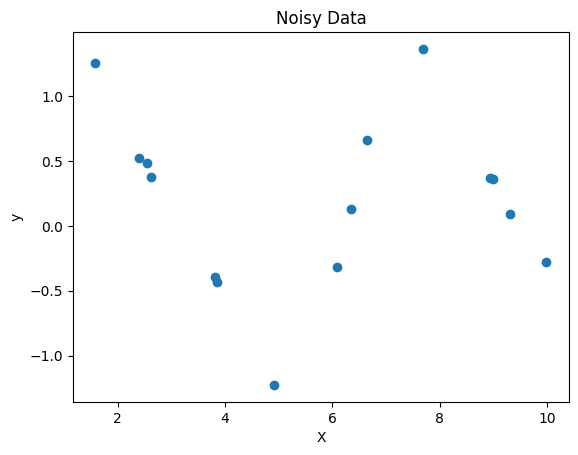

In [ ]:
rng = np.random.seed(204)
N = 15

x = 10 * np.random.rand(N).reshape(-1, 1)
y = 1.2 * np.sin(x) + 0.3 * np.sin(2 * x)
y_noisy = y + 0.1 * np.random.rand(N).reshape(-1, 1)

plt.scatter(x, y_noisy)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Noisy Data')
plt.show()

We have to set up the Gaussian process with a kernel. We will use the RBF kernel. Recall that the Radial Basis Function (RBF) kernel is defined as

$$ k(x, x') = \exp \left( - \frac{(x - x')^2}{2 \ell^2} \right) $$

Where ${l}$ is the length scale parameter.

We then use `GaussianProcessRegressor` to regress a Gaussian process to the data based on the set kernel. Changing the hyperparameter `alpha` effectively changes the RBF kernel's length scale.

In [ ]:
kernel = RBF(length_scale = 0.5, length_scale_bounds = 'fixed')
gp_regressor = GaussianProcessRegressor(kernel = kernel, alpha = 1e-3, normalize_y = False)
gp_regressor.fit(x, y_noisy)
print(f"RBF Lengthscale: {gp_regressor.kernel_}")

RBF Lengthscale: RBF(length_scale=0.5)


Finally, we generate new datapoints and plot the predictions. Set `x_star` such that it covers sufficient number of data points evenly distributed in the range you wish to make predictions.

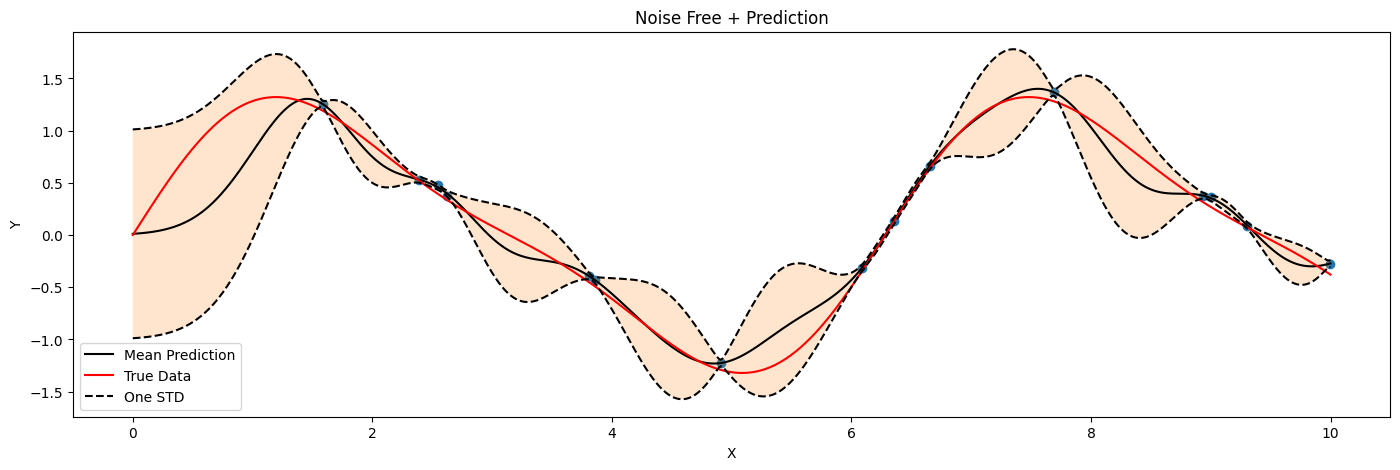

In [ ]:
x_star = np.linspace(0, 10, 1000).reshape(-1, 1)
y_star_true = 1.2 * np.sin(x_star) + 0.3 * np.sin(2 * x_star)
y_pred_mean, y_pred_std = gp_regressor.predict(x_star, return_std = True)


f = plt.figure(figsize=[17.0, 5.0])
ax = f.add_subplot(111)
ax.scatter(x, y_noisy);
ax.plot(np.squeeze(x_star), np.squeeze(y_pred_mean), 'k-', label='Mean Prediction')
ax.plot(np.squeeze(x_star), np.squeeze(y_star_true), 'r-', label='True Data')
ax.plot(np.squeeze(x_star), np.squeeze(y_pred_mean) + y_pred_std, 'k--', label='One STD')
ax.plot(np.squeeze(x_star), np.squeeze(y_pred_mean) - y_pred_std, 'k--')
ax.fill_between(np.squeeze(x_star), np.squeeze(y_pred_mean) + y_pred_std, np.squeeze(y_pred_mean) - y_pred_std, alpha=0.2)
ax.set_xlabel('X');
ax.set_ylabel('Y');
ax.set_title('Noise Free + Prediction');
ax.legend(loc='lower left');

Play around with `alpha` of the `GaussianProcessRegressor` and the `RBF` length scale to get different GP fits.

#### Exercise 1
Iterate over the values given in array `l` below and fit a GP to the data. Compare and plot the results.

In [ ]:
l = [] # Complete this part

In [ ]:
fig, axes = plt.subplots(1, len(l), figsize=(40, 5), sharey = True)
x_star = # Complete this part

for i in range(len(l)):

  # Complete this part


  ax = axes[i]
  ax.scatter(x, y_noisy, c = 'k', label = 'Data')
  ax.plot(x_star, y_pred_mean, 'b-', label='$\mu$')
  ax.fill_between(x_star.ravel(), y_pred_mean - 2 * y_pred_std, y_pred_mean + 2 * y_pred_std,
                 alpha = 0.2, color='blue', label='$\pm2\sigma$')

  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_ylim([-5, 5]);
  ax.set_xlim([0, 10]);
  ax.set_title(gp_regressor.kernel_)
  ax.legend();

SyntaxError: invalid syntax (1471703549.py, line 2)

#### Exercise 2
Try with different kernels and fit a GP to the data. Compare and plot the resutls.

In [ ]:
l = [] # Complete this part

In [ ]:
# Complete this part


# Active Learning


In this tutorial, we aim to make prediction using Gaussian Process Regression by iteratively adding one data point at a time. The GP model relearns the distribution after the additon of each new data point. The model becomes more accurate and robust after each iteration.

First, we import the necessary libraries.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

We need to generate random datapoints, and define a 'true function'.

In [ ]:
def true_function(x):
    y = np.sin(np.pi * 2 * x) + 3 * np.sin(np.pi * (x + 0.2)) + np.sin(np.pi * 10 * (x + 0.4))
    return y

The true function is not accessible by GP, but we later use it to generate datapoints from it one by one.

In [ ]:
np.random.seed(2000)
N = 100
x = np.linspace(0, 1, N)
y = true_function(x)

Let's see how the data looks.

In [ ]:
plt.figure(figsize = (10,8))
plt.plot(x, y, "k--", label = "Ground Truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Now that we have the true function, we pick random points from [0, 1.0], obtain true function value and regress using GPR. First, let's fit the GPR with 5 starting points.

In [ ]:
starting_measurements = 5

x_measured = np.random.rand(5)
y_measured = true_function(x_measured)

#Plot the measurements alongside the ground truth
plt.figure(figsize = (10,8))
plt.scatter(x_measured, y_measured, label = "Measurements")
plt.plot(x, y, "k--", label = "Ground Truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

We define a function, `train_gpr`, which returns a regressed GP given a training pair (x, y).*italicized text*

In [ ]:
def train_gpr(training_x, training_y):

  kernel = RBF()
  gp_regressor = GaussianProcessRegressor(kernel = kernel, alpha = 1, normalize_y = False)
  gp_regressor.fit(training_x, training_y)

  return gp_regressor.predict(x.reshape(-1, 1), return_std = True)

Calling the function and plotting:

In [ ]:
y_pred_mean, y_pred_std = train_gpr(x_measured.reshape(-1, 1), y_measured.reshape(-1, 1))

plt.figure(figsize=(10, 8))
plt.plot(x, y_pred_mean, "r-", linewidth=1, label = 'Mean')
plt.fill_between(x.ravel(), y_pred_mean - 2 * y_pred_std, y_pred_mean + 2 * y_pred_std,
                 alpha=0.2, color='blue', label='$\pm2\sigma$')

plt.scatter(x_measured, y_measured, label = "Measurements")
plt.plot(x, y, "k--", label = "Ground Truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.plot()

Now let's move on to adding one point at a time. First, write a function which returns where to sample next from the space of x. To speed things up, we add 20 points at a time.

In [ ]:
def next_sample(x, x_measured):
  x_measured = np.append(x_measured, np.random.rand(5))
  return x_measured, true_function(x_measured)

Now the loop: it calls `train_gpr` each time given new set of points. It does so 10 times.

In [ ]:
x_measured = np.random.rand(5)
y_measured = true_function(x_measured)

for i in range(10):
  x_measured, y_measured = next_sample(x, x_measured) # Obtain the new set of points
  y_pred_mean, y_pred_std = train_gpr(x_measured.reshape(-1, 1), y_measured.reshape(-1, 1)) # Run GPR

  #plot
  plt.figure(figsize=(10, 8))
  plt.plot(x, y_pred_mean, "r-", linewidth=1, label = 'Mean')
  plt.fill_between(x.ravel(), y_pred_mean - 2 * y_pred_std, y_pred_mean + 2 * y_pred_std,
                  alpha=0.2, color='blue', label='$\pm2\sigma$')

  plt.scatter(x_measured, y_measured, label = "Measurements")
  plt.plot(x, y, "k--", label = "Ground Truth")
  plt.xlabel("x")
  plt.ylabel("y")
  plt.legend()
  plt.plot()

#### Practice
Change alpha, RBF length scale and loop repeat until you obtain a proper fit to the data.